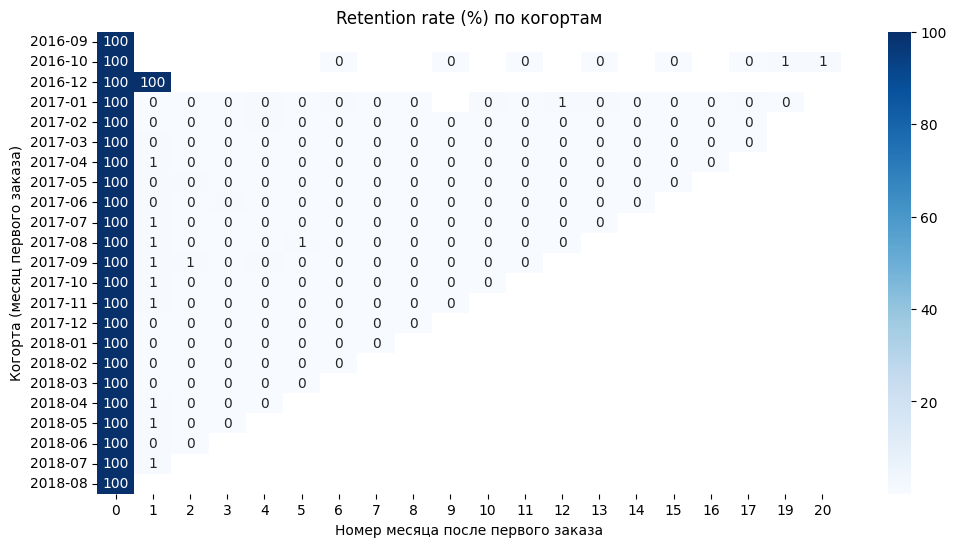

ROC-AUC на тесте: 1.000


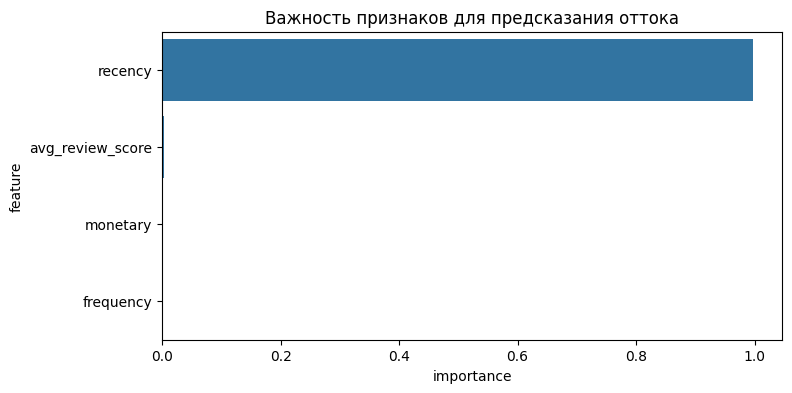

Модель сохранена


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px
import joblib

customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

for df in [orders, order_items, reviews, products]:
    for col in df.columns:
        if 'date' in col.lower() or 'timestamp' in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce')
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str)
payments['payment_value'] = pd.to_numeric(payments['payment_value'], errors='coerce')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_with_cust = orders_delivered.merge(customers, on='customer_id')
first_orders = orders_with_cust.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_orders.columns = ['customer_unique_id', 'first_purchase_date']
first_orders['cohort_month'] = first_orders['first_purchase_date'].dt.to_period('M')
orders_with_cohort = orders_with_cust.merge(first_orders[['customer_unique_id', 'cohort_month']], on='customer_unique_id')
orders_with_cohort['order_month'] = orders_with_cohort['order_purchase_timestamp'].dt.to_period('M')
orders_with_cohort['month_number'] = (orders_with_cohort['order_month'].dt.year - orders_with_cohort['cohort_month'].dt.year) * 12 + (orders_with_cohort['order_month'].dt.month - orders_with_cohort['cohort_month'].dt.month)
cohort_data = orders_with_cohort.groupby(['cohort_month', 'month_number'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='month_number', values='customer_unique_id')
retention_matrix = cohort_pivot.div(cohort_pivot[0], axis=0) * 100
plt.figure(figsize=(12, 6))
sns.heatmap(retention_matrix, annot=True, fmt='.0f', cmap='Blues')
plt.title('Retention rate (%) по когортам')
plt.ylabel('Когорта (месяц первого заказа)')
plt.xlabel('Номер месяца после первого заказа')
plt.show()

orders_with_cust = orders_with_cust.merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
rfm = orders_with_cust.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (pd.Timestamp.now() - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()
rfm.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']
rfm['r_score'] = pd.qcut(rfm['recency'].clip(lower=0), 5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'].clip(lower=0.01), 5, labels=[1,2,3,4,5])
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

def segment(score):
    if score in ['555','554','544','545','454','455']:
        return 'Champions'
    elif score in ['543','444','435','355','354','345','344','335']:
        return 'Loyal'
    elif score in ['553','551','552','541','542','533','532','531','452','442','432','431']:
        return 'Potential'
    elif score in ['512','511','422','421','412','411','311']:
        return 'At Risk'
    else:
        return 'Lost'
rfm['segment'] = rfm['rfm_score'].apply(segment)

cutoff_date = orders_with_cust['order_purchase_timestamp'].max() - pd.Timedelta(days=90)
last_purchase = orders_with_cust.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
last_purchase.columns = ['customer_unique_id', 'last_purchase']
last_purchase['churn'] = (last_purchase['last_purchase'] < cutoff_date).astype(int)
churn_data = rfm.merge(last_purchase[['customer_unique_id', 'churn']], on='customer_unique_id')
reviews_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()
orders_with_reviews = orders_with_cust.merge(reviews_agg, on='order_id', how='left')
cust_avg_review = orders_with_reviews.groupby('customer_unique_id')['review_score'].mean().reset_index()
cust_avg_review.columns = ['customer_unique_id', 'avg_review_score']
churn_data = churn_data.merge(cust_avg_review, on='customer_unique_id', how='left')
churn_data['avg_review_score'].fillna(0, inplace=True)

features = ['recency', 'frequency', 'monetary', 'avg_review_score']
X = churn_data[features]
y = churn_data['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
best_rf = grid.best_estimator_
y_pred_proba = best_rf.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC на тесте: {roc_auc:.3f}")

importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(data=feature_importance_df, x='importance', y='feature')
plt.title('Важность признаков для предсказания оттока')
plt.show()

joblib.dump(best_rf, 'random_forest_churn.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Модель сохранена")